In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

plt.style.use('jlab.mplstyle')

# --- Global constants ---
k_b       = 1.380649e-23  # J/K
T         = 297.7         # K  (20°C)
R         = 475000        # Ω
f_mask    = 200_000       # Hz — upper frequency cutoff for gain integration
correct_Vi = False         # True: assume V_input constant at its low-freq value
f_display = 100_000       # Hz — upper frequency limit for all plots

# --- Load CSV ---
raw = pd.read_csv('shot_calibration_1mV.csv',
                  names=['freq', 'V_i', 'dV_i', 'V_f', 'dV_f'],
                  skiprows=1)
raw['freq'] = pd.to_numeric(raw['freq'], errors='coerce')
for col in ['V_i', 'dV_i', 'V_f', 'dV_f']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

df = raw.dropna(subset=['V_f', 'dV_f']).copy()
df = df.set_index('freq').sort_index()

df['V_i']  = df['V_i'].interpolate(method='index')
df['dV_i'] = df['dV_i'].interpolate(method='index')

# --- Estimate constant output voltage offset ---
hi = df.index >= 200_000
w_hi = 1 / df['dV_f'][hi]**2
V_offset     = float(np.sum(w_hi * df['V_f'][hi]) / np.sum(w_hi))
dV_offset    = float(1 / np.sqrt(np.sum(w_hi)))

lo = df.index <= 300
w_lo = 1 / df['dV_f'][lo]**2
V_offset_lo  = float(np.sum(w_lo * df['V_f'][lo]) / np.sum(w_lo))
dV_offset_lo = float(1 / np.sqrt(np.sum(w_lo)))

consistency = abs(V_offset - V_offset_lo) / np.sqrt(dV_offset**2 + dV_offset_lo**2)
print(f"V_offset (200 kHz – 1 MHz) : {V_offset:.3f} ± {dV_offset:.3f} mV  [primary]")
print(f"V_offset (100 – 300 Hz)    : {V_offset_lo:.3f} ± {dV_offset_lo:.3f} mV  [check]")
print(f"Consistency                : {consistency:.2f} σ")

# --- Corrected output voltage: subtract offset in quadrature ---
Vf2_corr = df['V_f']**2 - V_offset**2
Vf2_corr_clamped = Vf2_corr.clip(lower=0)
df['V_f_corr']  = np.sqrt(Vf2_corr_clamped)
df['dV_f_corr'] = np.where(
    df['V_f_corr'] > 0,
    np.sqrt((df['V_f'] * df['dV_f'])**2 + (V_offset * dV_offset)**2) / df['V_f_corr'],
    1e30
)

# --- V_input: use flat correction or measured ---
if correct_Vi:
    # Assume V_input constant at its low-frequency value (first data point)
    Vi_used  = float(df['V_i'].iloc[0])
    dVi_used = float(df['dV_i'].iloc[0])
    print(f"correct_Vi=True: using V_input = {Vi_used:.4f} mV (constant)")
else:
    Vi_used  = df['V_i']
    dVi_used = df['dV_i']

# --- Gain variant 1: raw (measured V_f, no offset correction) ---
gain_raw     = df['V_f'] / Vi_used
dgain_raw    = gain_raw * np.sqrt((df['dV_f']  / df['V_f'])**2
                                 + (dVi_used   / Vi_used)**2)
df['G_raw']  = gain_raw**2
df['dG_raw'] = 2 * gain_raw * dgain_raw

# --- Gain variant 2: V_offset corrected ---
gain_corr    = df['V_f_corr'] / Vi_used
dgain_corr   = gain_corr.abs() * np.sqrt((df['dV_f_corr'] / df['V_f_corr'].clip(lower=1e-30))**2
                                        + (dVi_used        / Vi_used)**2)
df['G']      = gain_corr**2
df['dG']     = 2 * gain_corr.abs() * dgain_corr

# Replace any remaining NaN/inf with sentinel
for col in ['dG_raw', 'dG']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(1e30)

print()
print(df[['V_f', 'V_f_corr', 'G_raw', 'G']].to_string())

V_offset (200 kHz – 1 MHz) : 77.750 ± 0.212 mV  [primary]
V_offset (100 – 300 Hz)    : 77.856 ± 0.249 mV  [check]
Consistency                : 0.32 σ

             V_f     V_f_corr          G_raw              G
freq                                                       
100        77.80     2.788817    3671.378383       4.717479
200        78.00     6.239992    3690.278627      23.617723
300        77.90     4.831925    3675.095762      14.139502
400        80.20    19.671744    3901.383915     234.723011
500        95.10    54.762647    5502.815900    1824.705633
600       143.40   120.492728   12472.923399    8806.262495
700       242.80   230.014733   35813.276196   32140.897303
800       395.50   387.782397   95025.390486   91353.011593
900       585.10   579.911155  207972.965010  204300.586117
1000      775.00   771.090097  365449.485374  361771.375106
2000     1203.00  1200.484876  880552.398383  876874.288115
3000     1215.00  1212.509768  898207.145134  894529.034867
4000     

/tmp/ipykernel_7942/936819991.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


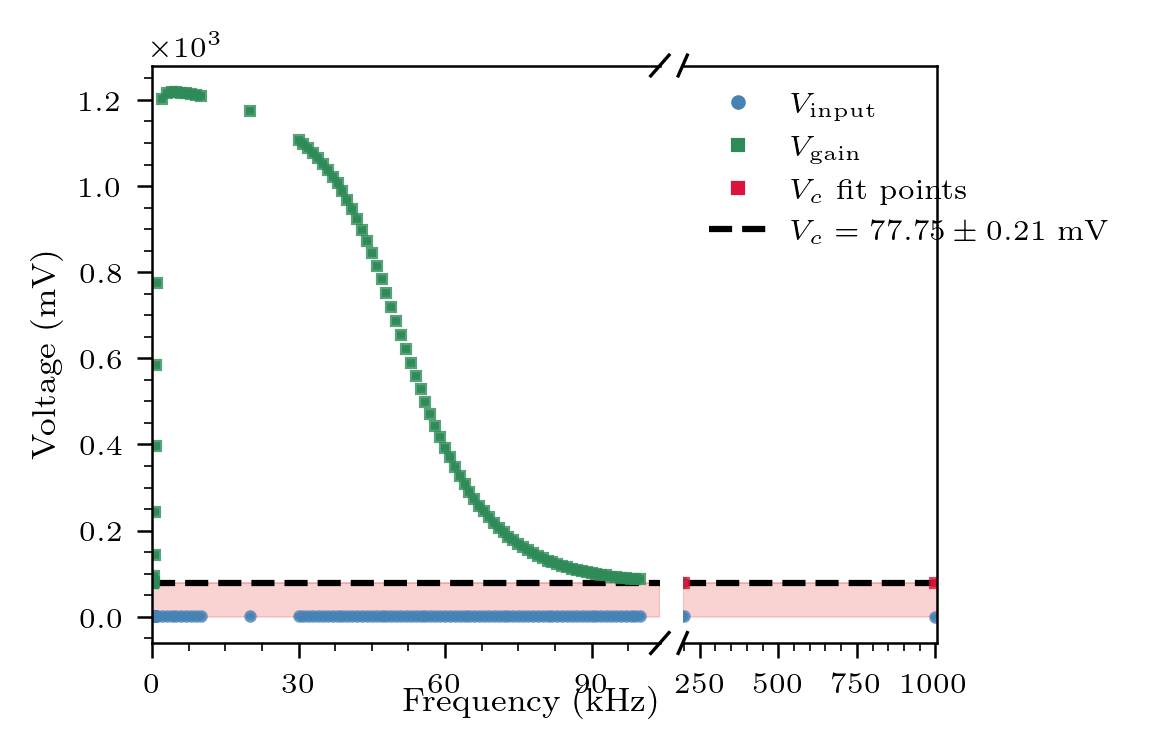

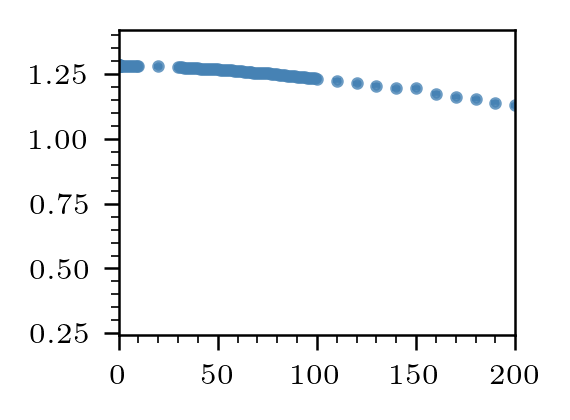

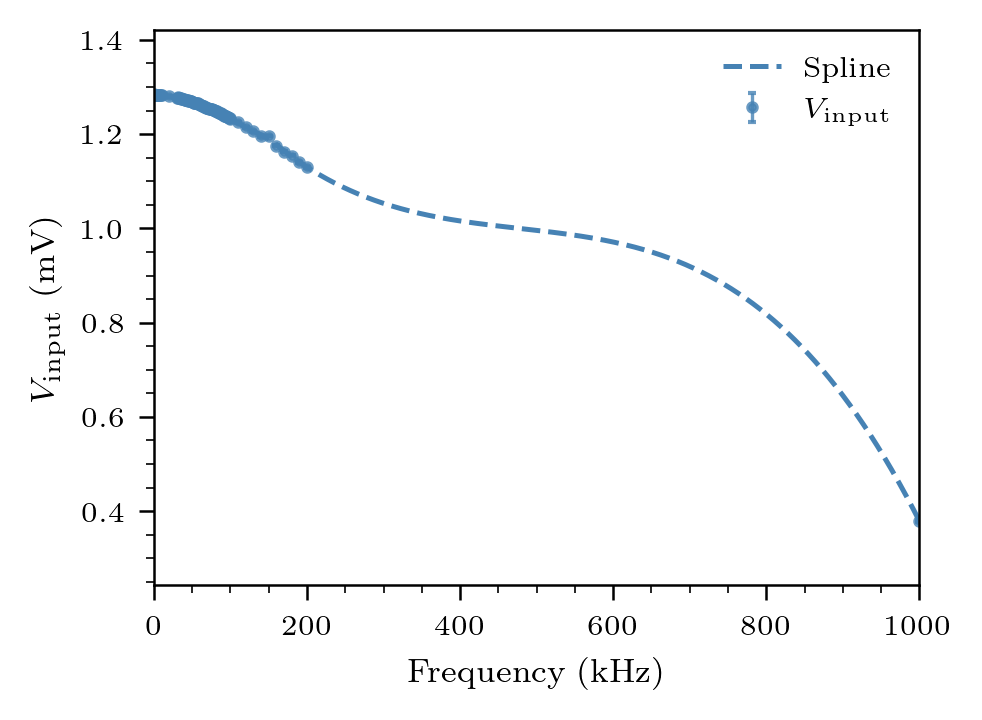

f_mask = 200000 Hz  →  101 data point(s) included
Quantity                                    Value    Uncertainty   Units
------------------------------------------------------------------------------
Area under g² (raw)                  3.8999e+10   2.9037e+07   Hz
Area under g² (V_offset corr.)       3.8202e+10   2.9009e+07   Hz


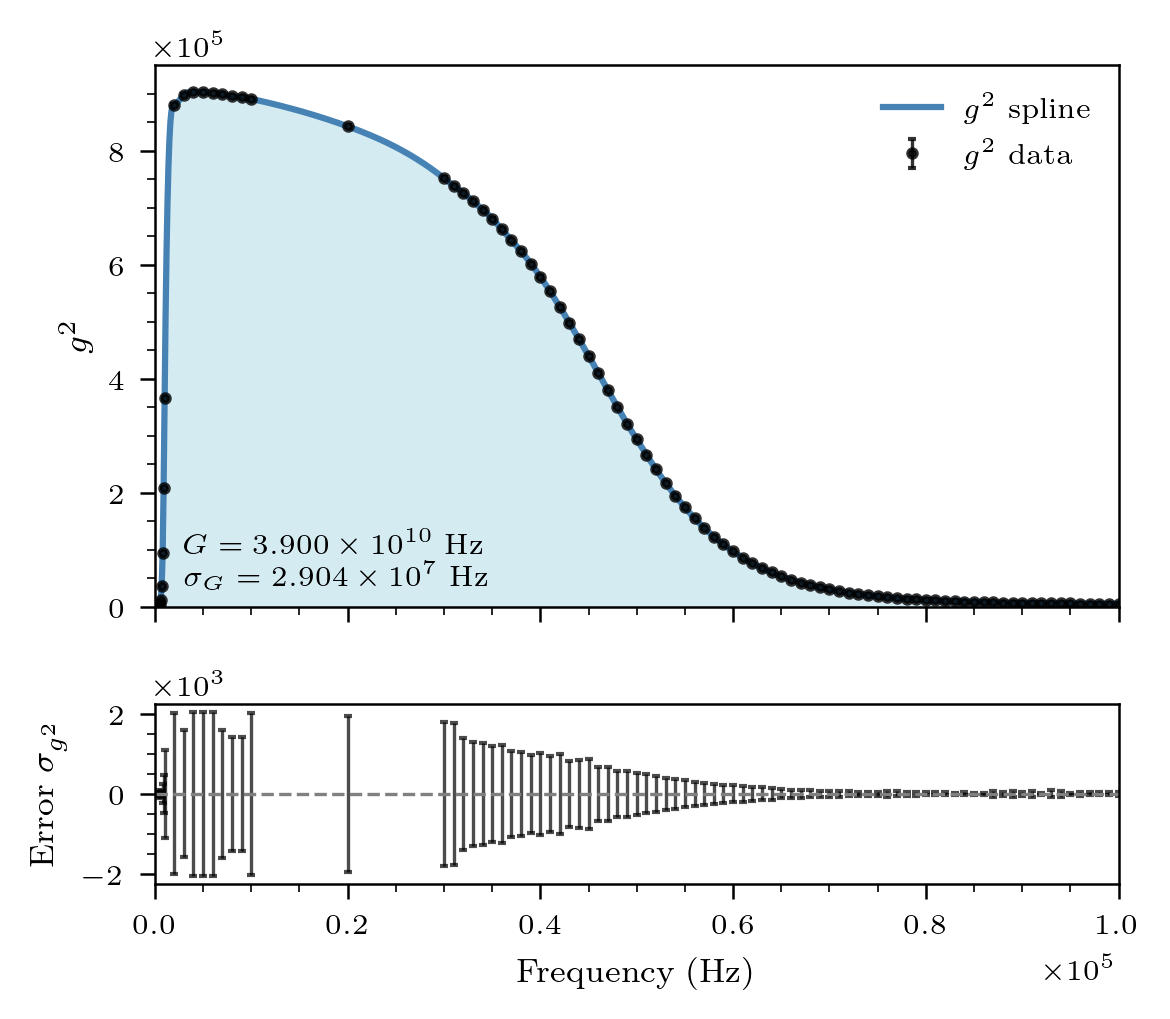

In [102]:
# --- Plot 1: raw calibration data, broken x-axis (0–100 kHz and 200–1000 kHz) ---
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from matplotlib.lines import Line2D

freq_data     = df.index.to_numpy(dtype=float)
freq_data_khz = freq_data / 1e3          # convert to kHz for display
V_f_data  = df['V_f'].to_numpy()
dV_f_data = df['dV_f'].to_numpy()
V_i_data  = df['V_i'].to_numpy()
dV_i_data = df['dV_i'].to_numpy()

fig0, (ax0L, ax0R) = plt.subplots(
    1, 2, figsize=(3.375, 2.5), sharey=True,
    gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.06}
)

# split V_gain into noise-floor-fit points and regular points
nf_mask   = freq_data >= 200_000        # used to fit V_c
reg_mask  = ~nf_mask

for ax in (ax0L, ax0R):
    ax.axhspan(0, V_offset, color='lightcoral', alpha=0.35, zorder=0)
    ax.axhline(V_offset, color='black', lw=1.5, ls='--', zorder=2)
    ax.axhspan(V_offset - dV_offset, V_offset + dV_offset, color='red', alpha=0.15, zorder=1)
    ax.errorbar(freq_data_khz, V_i_data, yerr=dV_i_data,
                fmt='o', ms=2, lw=0.8, color='steelblue', ecolor='steelblue', alpha=0.8)
    # V_gain: regular points in green
    ax.errorbar(freq_data_khz[reg_mask], V_f_data[reg_mask], yerr=dV_f_data[reg_mask],
                fmt='s', ms=2, lw=0.8, color='seagreen', ecolor='seagreen', alpha=0.8)
    # V_gain: noise-floor fit points in red
    ax.errorbar(freq_data_khz[nf_mask], V_f_data[nf_mask], yerr=dV_f_data[nf_mask],
                fmt='s', ms=2, lw=0.8, color='crimson', ecolor='crimson', alpha=0.8)
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(sf)

ax0L.set_xlim(0, 104)
ax0R.set_xlim(196, 1004)
ax0L.set_ylabel(r'Voltage (mV)')

ax0L.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='upper'))
ax0R.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='lower'))

ax0L.spines['right'].set_visible(False)
ax0R.spines['left'].set_visible(False)
ax0R.tick_params(axis='y', which='both', left=False, labelleft=False)

d = 0.018
kw = dict(color='k', clip_on=False, lw=0.8, transform=ax0L.transAxes)
ax0L.plot((1-d, 1+d), (-d, +d), **kw)
ax0L.plot((1-d, 1+d), (1-d, 1+d), **kw)
kw.update(transform=ax0R.transAxes)
ax0R.plot((-d, +d), (-d, +d), **kw)
ax0R.plot((-d, +d), (1-d, 1+d), **kw)

fig0.supxlabel(r'Frequency (kHz)', fontsize=8)

legend_handles = [
    Line2D([0], [0], marker='o', color='steelblue', ms=2.5, lw=0, label=r'$V_{\rm input}$'),
    Line2D([0], [0], marker='s', color='seagreen',  ms=2.5, lw=0, label=r'$V_{\rm gain}$'),
    Line2D([0], [0], marker='s', color='crimson',   ms=2.5, lw=0, label=r'$V_c$ fit points'),
    Line2D([0], [0], color='black', lw=1.5, ls='--',
           label=rf'$V_c = {V_offset:.2f} \pm {dV_offset:.2f}$ mV'),
]
ax0R.legend(handles=legend_handles, fontsize=7)
plt.tight_layout()
fig0.savefig('calibration_raw.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: V_input close-up across full frequency range ---
freq_full     = df.index.to_numpy(dtype=float)
freq_full_khz = freq_full / 1e3
V_i_full      = df['V_i'].to_numpy()
dV_i_full     = df['dV_i'].to_numpy()

_vi_pad = (V_i_full.max() - V_i_full.min()) * 0.15
_vi_lo  = V_i_full.min() - _vi_pad
_vi_hi  = V_i_full.max() + _vi_pad

# --- Plot 2a: inset-sized V_input (0-200 kHz, no labels) ---
fig1, ax1 = plt.subplots(figsize=(2, 1.5))
ax1.errorbar(freq_full_khz, V_i_full, yerr=dV_i_full,
             fmt='o', ms=2, lw=0.8, color='steelblue', ecolor='steelblue', alpha=0.8)
ax1.set_xlim(0, 200)
ax1.set_ylim(_vi_lo, _vi_hi)
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((0, 0))
ax1.yaxis.set_major_formatter(sf)
plt.tight_layout()
fig1.savefig('noise_floor.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2b: V_input full range (0-1 MHz) with spline ---
_spl_vi = UnivariateSpline(freq_full, V_i_full, w=1/dV_i_full, s=len(freq_full))
_f_fine = np.linspace(freq_full[0], freq_full[-1], 2000)

fig1b, ax1b = plt.subplots(figsize=(3.375, 2.5))
ax1b.errorbar(freq_full_khz, V_i_full, yerr=dV_i_full,
              fmt='o', ms=2, lw=0.8, color='steelblue', ecolor='steelblue',
              alpha=0.8, label=r'$V_{\rm input}$')
ax1b.plot(_f_fine / 1e3, _spl_vi(_f_fine),
          color='steelblue', lw=1.2, ls='--', label='Spline')
ax1b.set_xlim(0, freq_full_khz.max())
ax1b.set_ylim(_vi_lo, _vi_hi)
ax1b.set_xlabel(r'Frequency (kHz)')
ax1b.set_ylabel(r'$V_{\rm input}$ (mV)')
sf2 = ScalarFormatter(useMathText=True)
sf2.set_powerlimits((0, 0))
ax1b.yaxis.set_major_formatter(sf2)
ax1b.legend(fontsize=7)
plt.tight_layout()
fig1b.savefig('vinput_full.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Restrict to freq <= f_mask ---
freq_mask = (df.index >= 0) & (df.index <= f_mask)
freq   = df.index[freq_mask].to_numpy(dtype=float)
G      = df['G'][freq_mask].to_numpy()
dG     = df['dG'][freq_mask].to_numpy()
G_raw  = df['G_raw'][freq_mask].to_numpy()
dG_raw = df['dG_raw'][freq_mask].to_numpy()

print(f"f_mask = {f_mask} Hz  →  {len(freq)} data point(s) included")

# --- Raw spline: no weights ---
spl_raw = UnivariateSpline(freq, G_raw)
area_G_raw     = spl_raw.integral(freq[0], freq[-1])
steps_all      = np.append(np.diff(freq), np.diff(freq)[-1])
area_G_raw_unc = np.sqrt(np.sum((dG_raw * steps_all)**2))

# --- Corrected spline ---
valid   = np.isfinite(dG) & (dG > 0) & (dG < 1e29)
freq_v  = freq[valid]
G_v     = G[valid]
dG_v    = dG[valid]

spl = UnivariateSpline(freq_v, G_v, w=1.0/dG_v, s=len(freq_v))

def integral_and_unc(spl, dg_v, freq_v):
    area  = spl.integral(freq_v[0], freq_v[-1])
    steps = np.append(np.diff(freq_v), np.diff(freq_v)[-1])
    unc   = np.sqrt(np.sum((dg_v * steps)**2))
    return area, unc

area_G, area_G_unc = integral_and_unc(spl, dG_v, freq_v)

print(f"{'Quantity':<35s}  {'Value':>12s}   {'Uncertainty':>12s}   Units")
print("-" * 78)
print(f"{'Area under g² (raw)':<35s}  {area_G_raw:.4e}   {area_G_raw_unc:.4e}   Hz")
print(f"{'Area under g² (V_offset corr.)':<35s}  {area_G:.4e}   {area_G_unc:.4e}   Hz")

# --- Gain plot ---
f_fine = np.linspace(freq[0], freq[-1], 2000)
f_disp = f_fine[f_fine <= f_display]

fig2, (ax, ax_gres) = plt.subplots(2, 1, figsize=(4.0, 3.5),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Only plot points with valid (finite, non-sentinel) uncertainties
valid_raw = np.isfinite(dG_raw) & (dG_raw > 0) & (dG_raw < 1e29)
freq_r, G_r, dG_r = freq[valid_raw], G_raw[valid_raw], dG_raw[valid_raw]

ax.fill_between(f_disp, 0, spl_raw(f_disp), color='lightblue', alpha=0.5, zorder=1)
ax.errorbar(freq_r, G_r, yerr=dG_r,
            fmt='o', ms=2, lw=0.8, color='black', ecolor='black',
            alpha=0.8, label=r'$g^2$ data')
ax.plot(f_fine, spl_raw(f_fine), color='steelblue', lw=1.5, label=r'$g^2$ spline')

for axis in (ax.xaxis, ax.yaxis):
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    axis.set_major_formatter(sf)

ax.set_ylabel(r'$g^2$')
ax.set_xlim(0, f_display)
ax.set_ylim(bottom=0)
ax.legend()
import math as _math_g
def _sci_g(v, p=3):
    e = int(_math_g.floor(_math_g.log10(abs(v))))
    m = v / 10**e
    return rf'{m:.{p}f} \times 10^{{{e}}}'
_g_txt = (rf'$G = {_sci_g(area_G_raw)}$ Hz' + '\n' +
          rf'$\sigma_G = {_sci_g(area_G_raw_unc)}$ Hz')
ax.text(0.03, 0.03, _g_txt,
        transform=ax.transAxes, ha='left', va='bottom', fontsize=7)

# Residuals: valid raw data vs raw spline
G_resid = G_r - spl_raw(freq_r)
ax_gres.errorbar(freq_r, G_resid, yerr=dG_r,
                 fmt='none', lw=0.8, color='black', ecolor='black', alpha=0.7)
ax_gres.axhline(0, color='gray', lw=0.8, ls='--')
for axis in (ax_gres.xaxis, ax_gres.yaxis):
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    axis.set_major_formatter(sf)
ax_gres.set_xlabel(r'Frequency (Hz)')
ax_gres.set_ylabel(r'Error $\sigma_{g^2}$')

plt.tight_layout()
fig2.savefig('gain_curve.png', dpi=300, bbox_inches='tight')
plt.show()

Fit A/f^8:  A = 1.5060e+43 +/- 9.2513e+39
chi2/DOF = 11969.76/40  (chi2/nu = 299.244),  p = 0.0000
Tail correction (f > 100 kHz): 2.1515e+07 +/- 1.3216e+04  Hz

Quantity                                           Value    Uncertainty   Units
-------------------------------------------------------------------------------------
Area under g2 (raw)                         3.8999e+10   2.9037e+07   Hz
Area under g2 (V_offset corr.)              3.8202e+10   2.9009e+07   Hz
Area under g2 (V_offset + tail corr.)       3.8224e+10   2.9009e+07   Hz


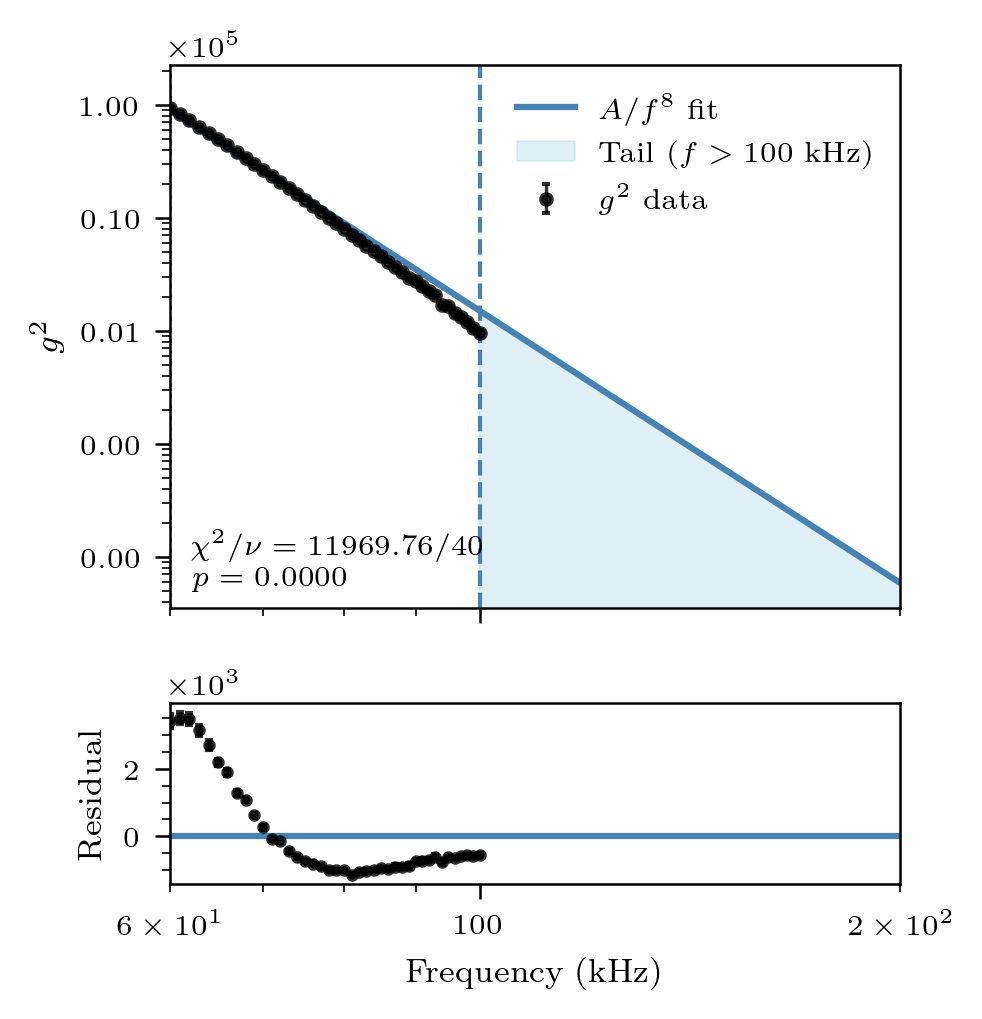

In [103]:
# --- Roll-off correction: fit A/f^8, integrate tail ---
from scipy.optimize import curve_fit
from scipy.stats import chi2 as chi2_dist
from matplotlib.ticker import ScalarFormatter, FuncFormatter

f_rolloff_Hz = 60_000   # Hz -- lower bound of fit region
f_tail       = 1e5      # Hz -- upper bound of fit / lower limit of tail integral
n_ro         = 8

mask_ro = (freq_v >= f_rolloff_Hz) & (freq_v <= f_tail)
freq_ro = freq_v[mask_ro]
G_ro    = G_v[mask_ro]
dG_ro   = dG_v[mask_ro]

def model_ro(f, A):
    return A / f**n_ro

popt, pcov = curve_fit(model_ro, freq_ro, G_ro,
                       sigma=dG_ro, absolute_sigma=True, p0=[1e40])
A_ro, A_ro_err = popt[0], np.sqrt(pcov[0, 0])

resid_ro = G_ro - model_ro(freq_ro, A_ro)
dof_ro   = len(freq_ro) - 1
chi2_ro  = float(np.sum((resid_ro / dG_ro)**2))
p_ro     = float(chi2_dist.sf(chi2_ro, df=dof_ro))

# Tail integral: A / ((n-1) * f_tail^(n-1))
tail_corr     = A_ro     / ((n_ro - 1) * f_tail**(n_ro - 1))
tail_corr_err = A_ro_err / ((n_ro - 1) * f_tail**(n_ro - 1))

area_G_corrected     = area_G + tail_corr
area_G_corrected_unc = np.sqrt(area_G_unc**2 + tail_corr_err**2)

print(f"Fit A/f^{n_ro}:  A = {A_ro:.4e} +/- {A_ro_err:.4e}")
print(f"chi2/DOF = {chi2_ro:.2f}/{dof_ro}  (chi2/nu = {chi2_ro/dof_ro:.3f}),  p = {p_ro:.4f}")
print(f"Tail correction (f > 100 kHz): {tail_corr:.4e} +/- {tail_corr_err:.4e}  Hz")
print()
print(f"{'Quantity':<42s}  {'Value':>12s}   {'Uncertainty':>12s}   Units")
print("-" * 85)
print(f"{'Area under g2 (raw)':<42s}  {area_G_raw:.4e}   {area_G_raw_unc:.4e}   Hz")
print(f"{'Area under g2 (V_offset corr.)':<42s}  {area_G:.4e}   {area_G_unc:.4e}   Hz")
print(f"{'Area under g2 (V_offset + tail corr.)':<42s}  {area_G_corrected:.4e}   {area_G_corrected_unc:.4e}   Hz")

# --- Plot (x-axis in kHz) ---
f_plot_max = 2e5
to_kHz = 1e-3

freq_ro_k  = freq_ro  * to_kHz
f_fine_k   = np.logspace(np.log10(f_rolloff_Hz * 0.95 * to_kHz),
                          np.log10(f_plot_max * to_kHz), 600)
f_shade_k  = np.logspace(np.log10(f_tail * to_kHz),
                          np.log10(f_plot_max * to_kHz), 400)

# Model in Hz from kHz input
def model_kHz(f_k, A):
    return A / (f_k * 1e3)**n_ro

fig_ro, (ax_ro, ax_res_ro) = plt.subplots(
    2, 1, figsize=(3.375, 3.5),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

ax_ro.errorbar(freq_ro_k, G_ro, yerr=dG_ro,
               fmt='o', ms=2.5, lw=0.8, color='black', ecolor='black',
               alpha=0.8, zorder=5, label=r'$g^2$ data')

ax_ro.plot(f_fine_k, model_kHz(f_fine_k, A_ro),
           color='steelblue', lw=1.5,
           label=rf'$A/f^{{{n_ro}}}$ fit')

ax_ro.fill_between(f_shade_k, model_kHz(f_shade_k, A_ro),
                   color='lightblue', alpha=0.4,
                   label=r'Tail ($f > 100$ kHz)')

ax_ro.axvline(f_rolloff_Hz * to_kHz, color='gray',      lw=1, ls=':')
ax_ro.axvline(f_tail       * to_kHz, color='steelblue', lw=1, ls='--')
ax_ro.set_xscale('log')
ax_ro.set_yscale('log')
ax_ro.set_ylabel(r'$g^2$')
ax_ro.set_xlim(f_rolloff_Hz * to_kHz, f_plot_max * to_kHz)
ax_ro.legend(fontsize=7)
ax_ro.text(0.03, 0.03,
           rf'$\chi^2/\nu = {chi2_ro:.2f}/{dof_ro}$' + '\n' + rf'$p = {p_ro:.4f}$',
           transform=ax_ro.transAxes,
           ha='left', va='bottom', fontsize=7)

ax_res_ro.errorbar(freq_ro_k, resid_ro, yerr=dG_ro,
                   fmt='o', ms=2, lw=0.8, color='black', ecolor='black', alpha=0.8)
ax_res_ro.axhline(0, color='steelblue', lw=1.5)

# Plain integer kHz labels on log x-axis
ax_res_ro.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
ax_res_ro.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_res_ro.yaxis.get_major_formatter().set_powerlimits((0, 0))

ax_ro.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax_ro.yaxis.get_major_formatter().set_powerlimits((0, 0))

ax_res_ro.set_xlabel(r'Frequency (kHz)')
ax_res_ro.set_ylabel(r'Residual')

plt.tight_layout()
fig_ro.savefig('rolloff_fit.png', dpi=300, bbox_inches='tight')
plt.show()


Slope = 1.4202e-08 ± 6.1343e-11  A
Const = 7.4836e-16 ± 1.6180e-16  A^2
χ²/DOF = 3.96/10  (χ²/ν = 0.396),  p = 0.9490

                                      e       σ_stat     σ_sys(R)        σ_tot   Disc.
--------------------------------------------------------------------------------------
raw gain                   1.8208e-19   7.8646e-22   1.8208e-21   1.9834e-21   11.02 σ
V_offset corrected         1.8588e-19   8.0286e-22   1.8588e-21   2.0247e-21   12.67 σ
V_offset + tail corr.      1.8577e-19   8.0241e-22   1.8577e-21   2.0236e-21   12.63 σ
e (true)                   1.6022e-19

Implied R if resistor is the sole source of error:
                            R_true (kΩ)     Unc (kΩ)      ΔR (kΩ)       ΔR/R
---------------------------------------------------------------------------
raw gain                         539.81         2.33        64.81     0.1364
V_offset corrected               551.07         2.38        76.07     0.1602
V_offset + tail corr.            550.76         2

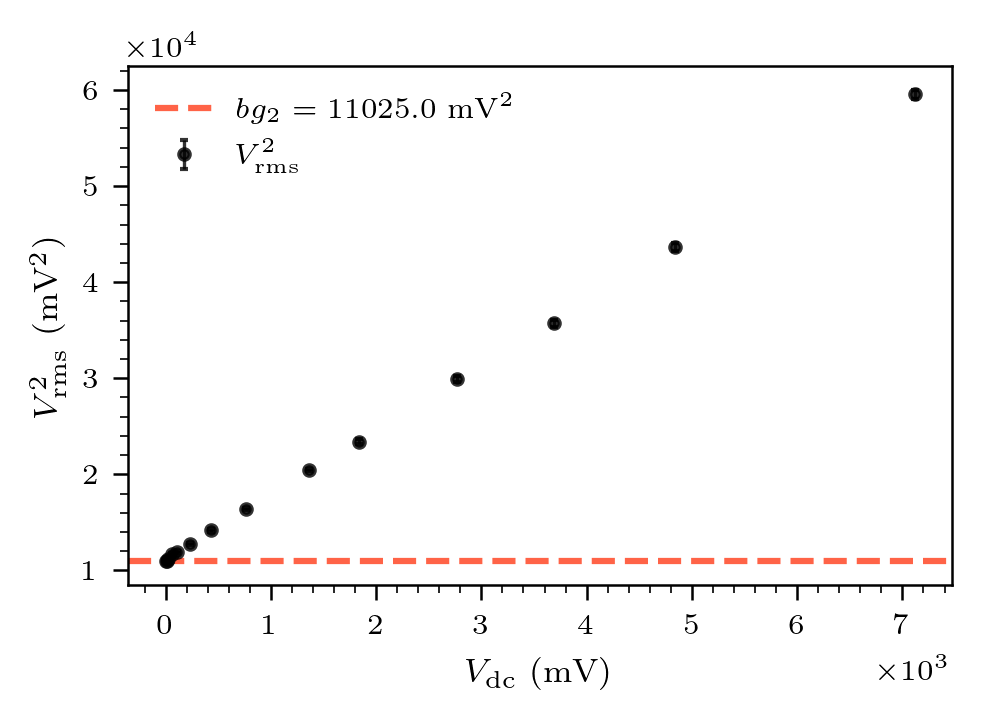

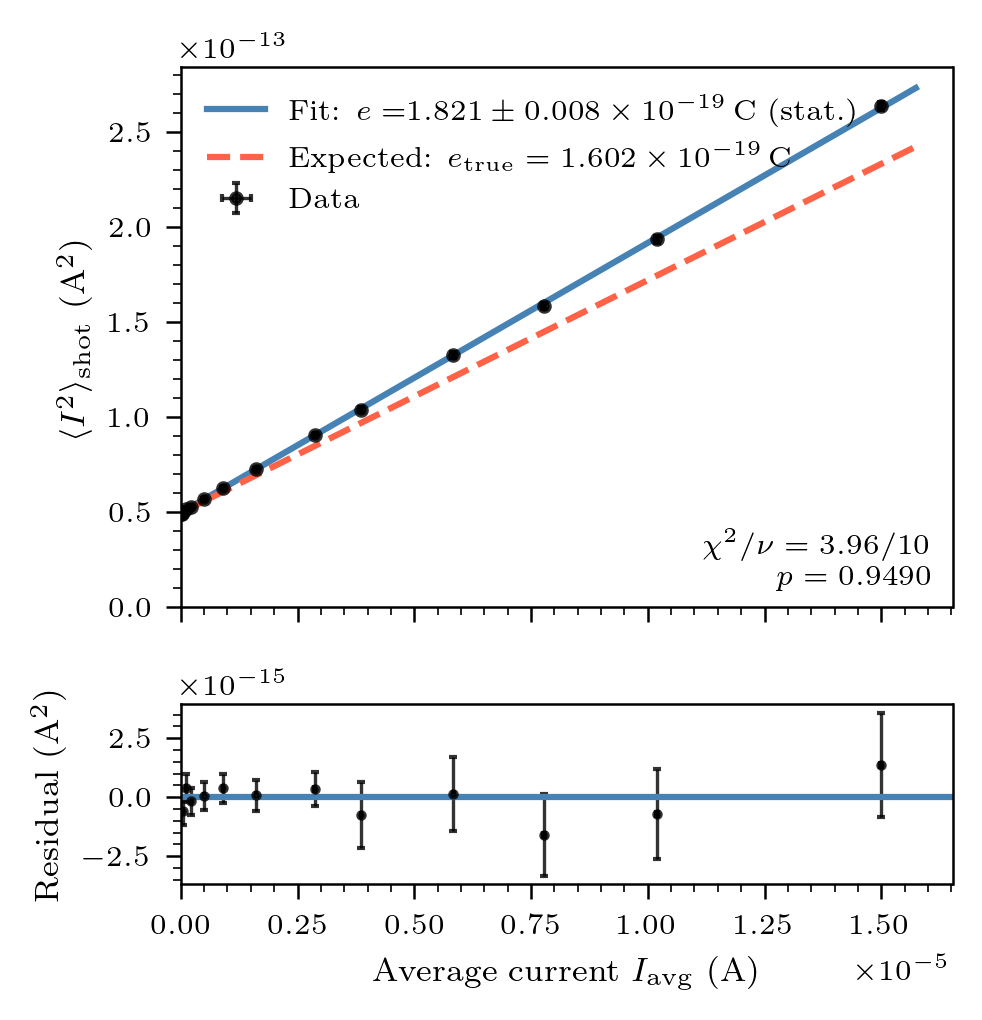

In [104]:
import math

def fmt_val_unc(val, unc, unit='C'):
    """Format val ± unc with 1 sig fig on unc, in scientific notation for MathTeX."""
    exp_unc = int(math.floor(math.log10(abs(unc))))
    exp_val = int(math.floor(math.log10(abs(val))))
    unc_r   = round(unc, -exp_unc)
    val_r   = round(val, -exp_unc)
    scale   = 10**exp_val
    n_dec   = max(0, exp_val - exp_unc)
    val_s   = val_r / scale
    unc_s   = unc_r / scale
    return rf'${val_s:.{n_dec}f} \pm {unc_s:.{n_dec}f} \times 10^{{{exp_val}}}$\,{unit}'

# --- Load shot noise data ---
sd = pd.read_csv('shot_data.csv',
                 names=['V_dc', 'dV_dc', 'V_rms', 'dV_rms'],
                 skiprows=1)

V_dc  = sd['V_dc'].to_numpy()  * 1e-3
dV_dc = sd['dV_dc'].to_numpy() * 1e-3
V_rms  = sd['V_rms'].to_numpy()  * 1e-3
dV_rms = sd['dV_rms'].to_numpy() * 1e-3

I  = V_dc / R
dI = dV_dc / R

Vrms2  = V_rms**2
dVrms2 = 2 * V_rms * dV_rms

bg2  = np.mean(Vrms2[:2])
dbg2 = np.sqrt(np.sum(dVrms2[:2]**2)) / 2
Vshot2  = Vrms2  - bg2
dVshot2 = np.sqrt(dVrms2**2 + dbg2**2)

shot_mask = np.arange(len(I)) >= 2
I_plot, dI_plot           = I[shot_mask], dI[shot_mask]
Vshot2_plot, dVshot2_plot = Vshot2[shot_mask], dVshot2[shot_mask]

Ishot2_plot  = Vshot2_plot  / R**2
dIshot2_plot = dVshot2_plot / R**2

# --- ODR fit ---
from scipy.odr import ODR, Model, RealData
from scipy.stats import chi2 as chi2_dist

def linear_const(beta, x):
    return beta[0] * x + beta[1]

data   = RealData(I_plot, Ishot2_plot, sx=dI_plot, sy=dIshot2_plot)
result = ODR(data, Model(linear_const), beta0=[1.0, 0.0]).run()
slope_I, slope_I_err = result.beta[0], result.sd_beta[0]
const_I, const_I_err = result.beta[1], result.sd_beta[1]

e_true  = 1.602176634e-19
dR_frac = 0.01

def e_from_area(area):
    val      = slope_I / (2 * area)
    stat_err = slope_I_err / (2 * area)
    sys_err  = val * dR_frac
    tot_err  = np.sqrt(stat_err**2 + sys_err**2)
    sig      = abs(val - e_true) / tot_err
    return val, stat_err, sys_err, tot_err, sig

e_raw,  s_raw,  r_raw,  t_raw,  sig_raw  = e_from_area(area_G_raw)
e_corr, s_corr, r_corr, t_corr, sig_corr = e_from_area(area_G)
e_full, s_full, r_full, t_full, sig_full = e_from_area(area_G_corrected)

residuals  = Ishot2_plot - (slope_I * I_plot + const_I)
sigma_eff  = np.sqrt(dIshot2_plot**2 + slope_I**2 * dI_plot**2)  # ODR effective sigma
dResiduals = sigma_eff
dof  = len(I_plot) - 2          # two free parameters: slope + const
chi2 = float(result.sum_square)  # ODR objective: sum of weighted orthogonal residuals^2
p_val = float(chi2_dist.sf(chi2, df=dof))

print(f"Slope = {slope_I:.4e} ± {slope_I_err:.4e}  A")
print(f"Const = {const_I:.4e} ± {const_I_err:.4e}  A^2")
print(f"χ²/DOF = {chi2:.2f}/{dof}  (χ²/ν = {chi2/dof:.3f}),  p = {p_val:.4f}")
print()
hdr = f"{'':25s}  {'e':>12s}   {'σ_stat':>10s}   {'σ_sys(R)':>10s}   {'σ_tot':>10s}   Disc."
print(hdr)
print("-" * len(hdr))
for label, val, stat, sys, tot, sig in [
        ('raw gain',              e_raw,  s_raw,  r_raw,  t_raw,  sig_raw),
        ('V_offset corrected',     e_corr, s_corr, r_corr, t_corr, sig_corr),
        ('V_offset + tail corr.',  e_full, s_full, r_full, t_full, sig_full)]:
    print(f"{label:25s}  {val:.4e}   {stat:.4e}   {sys:.4e}   {tot:.4e}   {sig:.2f} σ")
print(f"{'e (true)':25s}  {e_true:.4e}")

print()
print("Implied R if resistor is the sole source of error:")
print(f"{'':25s}  {'R_true (kΩ)':>12s}   {'Unc (kΩ)':>10s}   {'ΔR (kΩ)':>10s}   {'ΔR/R':>8s}")
print("-" * 75)
for label, val, stat in [('raw gain', e_raw, s_raw),
                          ('V_offset corrected', e_corr, s_corr),
                          ('V_offset + tail corr.', e_full, s_full)]:
    R_true     = R * val / e_true
    R_true_err = R * stat / e_true
    dR         = R_true - R
    print(f"{label:25s}  {R_true/1e3:12.2f}   {R_true_err/1e3:10.2f}   {dR/1e3:10.2f}   {dR/R:8.4f}")

# --- Plot ---
from matplotlib.ticker import ScalarFormatter

I_fine           = np.linspace(0, I_plot.max() * 1.05, 500)
Ishot2_fit       = slope_I * I_fine + const_I
slope_expected_I = 2 * e_true * area_G
Ishot2_expected  = slope_expected_I * I_fine + const_I

e_true_exp = int(math.floor(math.log10(e_true)))
e_true_man = e_true / 10**e_true_exp

label_fit      = r'Fit: $e = $' + fmt_val_unc(e_raw, s_raw) + r' (stat.)'
label_expected = rf'Expected: $e_{{\rm true}} = {e_true_man:.3f} \times 10^{{{e_true_exp}}}$\,C'

# Raw voltage-domain data (before bg subtraction and R conversion)
V_dc_all  = V_dc           # all points including near-zero
Vrms2_all = Vrms2
dVrms2_all = dVrms2

fig_raw, ax_raw = plt.subplots(figsize=(3.375, 2.5))
ax_raw.errorbar(V_dc_all * 1e3, Vrms2_all * 1e6,
                yerr=dVrms2_all * 1e6,
                fmt='o', ms=2.5, lw=0.8, color='black', ecolor='black', alpha=0.8,
                label=r'$V_{\rm rms}^2$')
ax_raw.axhline(bg2 * 1e6, color='tomato', lw=1.5, ls='--',
               label=rf'$bg_2 = {bg2*1e6:.1f}$ mV$^2$')
for axis in (ax_raw.xaxis, ax_raw.yaxis):
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    axis.set_major_formatter(sf)
ax_raw.set_xlabel(r'$V_{\rm dc}$ (mV)')
ax_raw.set_ylabel(r'$V_{\rm rms}^2$ (mV$^2$)')
ax_raw.legend(fontsize=7)
plt.tight_layout()
plt.show()

fig3, (ax_main, ax_res) = plt.subplots(
    2, 1, figsize=(3.375, 3.5),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

# Raw data (before bg subtraction)
Iraw2_all  = Vrms2  / R**2
dIraw2_all = dVrms2 / R**2
raw_intercept = const_I + bg2 / R**2
ax_main.errorbar(I, Iraw2_all,
                 xerr=dI, yerr=dIraw2_all,
                 fmt='o', ms=2.5, lw=0.8, color='black', ecolor='black',
                 alpha=0.8, label='Data', zorder=3)

# Fit line through raw data (same slope from ODR, intercept shifted up by bg2/R^2)
ax_main.plot(I_fine, slope_I          * I_fine + raw_intercept, color='steelblue', lw=1.5, label=label_fit)
# Expected line with true e, same intercept
ax_main.plot(I_fine, slope_expected_I * I_fine + raw_intercept, color='tomato',    lw=1.5, ls='--', label=label_expected)

for axis in (ax_main.xaxis, ax_main.yaxis):
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    axis.set_major_formatter(sf)

ax_main.set_ylabel(r'$\langle I^2 \rangle_{\rm shot}$ (A$^2$)')
ax_main.legend(fontsize=7, loc='upper left')
ax_main.set_xlim(left=0)
ax_main.set_ylim(bottom=0)
ax_main.text(0.97, 0.03,
             rf'$\chi^2/\nu = {chi2:.2f}/{dof}$' + '\n' + rf'$p = {p_val:.4f}$',
             transform=ax_main.transAxes,
             ha='right', va='bottom', fontsize=7)

ax_res.errorbar(I_plot, residuals,
                xerr=dI_plot, yerr=dResiduals,
                fmt='o', ms=1.5, lw=0.8, color='black', ecolor='black', alpha=0.8)
ax_res.axhline(0, color='steelblue', lw=1.5)

for axis in (ax_res.xaxis, ax_res.yaxis):
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((0, 0))
    axis.set_major_formatter(sf)

ax_res.set_xlabel(r'Average current $I_{\rm avg}$ (A)')
ax_res.set_ylabel(r'Residual (A$^2$)')

plt.tight_layout()
fig3.savefig('shot_noise.png', dpi=300, bbox_inches='tight')
plt.show()


In [105]:
# --- Systematic error summary ---

# Compute e from fully corrected G (V_c + tail)
e_full, s_full, r_full, t_full, sig_full = e_from_area(area_G_corrected)
G_best = area_G_corrected
e_best = e_full

# Corrections (systematic shifts on e)
delta_G_Vc   = area_G_raw - area_G             # noise-floor removes from G -> e increases
delta_e_Vc   =  e_best * delta_G_Vc  / G_best
delta_G_tail = tail_corr                        # tail adds to G -> e decreases
delta_e_tail = -e_best * delta_G_tail / G_best

# Systematic uncertainties
sigma_e_stat = e_best * slope_I_err / slope_I
sigma_e_R    = e_best * dR_frac
sigma_e_G    = e_best * area_G_unc   / G_best
sigma_e_tail = e_best * tail_corr_err / G_best

sigma_sys  = np.sqrt(sigma_e_R**2 + sigma_e_G**2 + sigma_e_tail**2)
sigma_full = np.sqrt(sigma_e_stat**2 + sigma_sys**2)

# --------------------------------------------------------------------------
# Plain-text table
# --------------------------------------------------------------------------
C1, C4, C5 = 40, 13, 10
W = C1 + C4 + C5 + 6

hdr  = f"  {'Source':<{C1}}  {'Value (C)':>{C4}}  {'Rel. to e':>{C5}}"
sep  = "  " + "-" * (W - 2)
sep2 = "  " + "=" * (W - 2)

print(sep2)
print(f"  Systematics Summary -- Shot Noise Measurement of e")
print(sep2)
print(f"\n  Best estimate:  e = {e_best:.4e} C     e_true = {e_true:.4e} C     discrepancy = {sig_full:.2f} sigma\n")
print(hdr)
print(sep)

print(f"  Corrections (systematic shifts applied to e)")
corr_rows = [
    ("Noise-floor subtraction (V_c)", delta_e_Vc,  delta_e_Vc  / e_best),
    ("Tail model (f > 100 kHz)",      delta_e_tail, delta_e_tail / e_best),
]
for name, val, rel in corr_rows:
    sign = "+" if val >= 0 else ""
    print(f"  {name:<{C1}}  {sign}{val:>{C4-1}.3e}  {sign}{100*rel:>{C5-1}.3f}%")
delta_e_total_corr = delta_e_Vc + delta_e_tail
sign = "+" if delta_e_total_corr >= 0 else ""
print(f"  {'Total Correction':<{C1}}  {sign}{delta_e_total_corr:>{C4-1}.3e}  {sign}{100*delta_e_total_corr/e_best:>{C5-1}.3f}%")

print(sep)
print(f"  Uncertainties")
unc_rows = [
    ("Statistical (ODR slope)",       sigma_e_stat),
    ("Resistor R (0.1% tolerance)",   sigma_e_R),
    ("Gain integral G",               sigma_e_G),
    ("Tail model (f > 100 kHz)",      sigma_e_tail),
]
for name, val in unc_rows:
    rel = val / e_best
    print(f"  {name:<{C1}}  {val:>{C4}.3e}  {100*rel:>{C5}.3f}%")

print(sep)
totals = [
    ("Total Statistical",             sigma_e_stat),
    ("Total Systematic",              sigma_sys),
    ("Total Uncertainty",             sigma_full),
]
for name, val in totals:
    rel = val / e_best
    print(f"  {name:<{C1}}  {val:>{C4}.3e}  {100*rel:>{C5}.3f}%")
print(sep2)

# --------------------------------------------------------------------------
# LaTeX tables
# --------------------------------------------------------------------------
import math as _math

def _sci(val, prec=2):
    """Signed scalar for corrections (+ or -)."""
    sign = "+" if val >= 0 else "-"
    av = abs(val)
    exp = int(_math.floor(_math.log10(av)))
    man = av / 10**exp
    return f"${sign}{man:.{prec}f} \\times 10^{{{exp}}}$"

def _sci_unc(val, prec=2):
    """Bidirectional (±) scalar for uncertainties."""
    av = abs(val)
    exp = int(_math.floor(_math.log10(av)))
    man = av / 10**exp
    return f"$\\pm{man:.{prec}f} \\times 10^{{{exp}}}$"

def _pct(rel, prec=2):
    """Signed percentage for corrections."""
    sign = "+" if rel >= 0 else ""
    return f"${sign}{100*rel:.{prec}f}\\%$"

def _pct_unc(rel, prec=2):
    """Bidirectional (±) percentage for uncertainties."""
    return f"$\\pm{100*abs(rel):.{prec}f}\\%$"

delta_e_total_corr = delta_e_Vc + delta_e_tail

# --- Table 1: Corrections ---
_tex1 = []
_tex1.append(r"\begin{table}[h]")
_tex1.append(r"\centering")
_tex1.append(r"\begin{tabular}{lrr}")
_tex1.append(r"\toprule")
_tex1.append(r"\textbf{Source} & \textbf{Value (C)} & \textbf{Rel.\ to $e$} \\")
_tex1.append(r"\midrule")
for _name, _val in [
        (r"Noise-floor subtraction ($V_c$)",      delta_e_Vc),
        (r"Tail model ($f > 100\,\mathrm{kHz}$)", delta_e_tail)]:
    _tex1.append(f"\\quad {_name} & {_sci(_val)} & {_pct(_val/e_best)} \\\\")
_tex1.append(r"\midrule")
_tex1.append(f"\\textbf{{Total Correction}} & {_sci(delta_e_total_corr)} & {_pct(delta_e_total_corr/e_best)} \\\\")
_tex1.append(r"\bottomrule")
_tex1.append(r"\end{tabular}")
_tex1.append(r"\caption{Systematic corrections applied to the shot-noise measurement of $e$.}")
_tex1.append(r"\label{tab:corrections}")
_tex1.append(r"\end{table}")

# --- Table 2: Uncertainties ---
_tex2 = []
_tex2.append(r"\begin{table}[h]")
_tex2.append(r"\centering")
_tex2.append(r"\begin{tabular}{lrr}")
_tex2.append(r"\toprule")
_tex2.append(r"\textbf{Source} & \textbf{Value (C)} & \textbf{Rel.\ to $e$} \\")
_tex2.append(r"\midrule")
for _name, _val in [
        (r"Statistical (ODR slope)",              sigma_e_stat),
        (r"Resistor $R$ (0.1\% tolerance)",       sigma_e_R),
        (r"Gain integral $\mathcal{G}$",          sigma_e_G),
        (r"Tail model ($f > 100\,\mathrm{kHz}$)", sigma_e_tail)]:
    _tex2.append(f"\\quad {_name} & {_sci_unc(_val, 2)} & {_pct_unc(_val/e_best)} \\\\")
_tex2.append(r"\midrule")
for _name, _val in [
        (r"\textbf{Total Statistical}", sigma_e_stat),
        (r"\textbf{Total Systematic}",  sigma_sys),
        (r"\textbf{Total Uncertainty}", sigma_full)]:
    _tex2.append(f"{_name} & {_sci_unc(_val, 2)} & {_pct_unc(_val/e_best)} \\\\")
_tex2.append(r"\bottomrule")
_tex2.append(r"\end{tabular}")
_tex2.append(r"\caption{Uncertainties on the shot-noise measurement of $e$.}")
_tex2.append(r"\label{tab:uncertainties}")
_tex2.append(r"\end{table}")

print("\n--- Corrections table ---")
print("\n".join(_tex1))
print("\n--- Uncertainties table ---")
print("\n".join(_tex2))

# --------------------------------------------------------------------------
# Final result statement
# --------------------------------------------------------------------------
import math as _math2

_exp_ref   = int(_math2.floor(_math2.log10(abs(e_best))))
_scale     = 10**_exp_ref

_e_man     = e_best       / _scale
_stat_man  = sigma_e_stat / _scale
_sys_man   = sigma_sys    / _scale

_ref_unc   = min(sigma_e_stat, sigma_sys)
_unc_exp   = int(_math2.floor(_math2.log10(_ref_unc / _scale)))
_ndec      = max(0, -_unc_exp)

_e_r    = round(_e_man,    _ndec)
_stat_r = round(_stat_man, _ndec)
_sys_r  = round(_sys_man,  _ndec)
_tot_r  = round(sigma_full / _scale, _ndec)

fmt = f".{_ndec}f"
print("=" * 70)
print("  Final Result")
print("=" * 70)
print(f"  e = ( {_e_r:{fmt}}  +/-  {_stat_r:{fmt}} (stat)  +/-  {_sys_r:{fmt}} (sys) ) x 10^{{{_exp_ref}}} C")
print(f"    = ( {_e_r:{fmt}}  +/-  {_tot_r:{fmt}} (total) ) x 10^{{{_exp_ref}}} C")
print(f"  e_true = {e_true/_scale:{fmt}} x 10^{{{_exp_ref}}} C")
print("=" * 70)

print()
print("LaTeX:")
print(f"$e = \\left( {_e_r:{fmt}} \\pm {_stat_r:{fmt}}_{{\\rm stat}} \\pm {_sys_r:{fmt}}_{{\\rm sys}} \\right) \\times 10^{{{{{_exp_ref}}}}}\\,\\text{{C}}$")


  Systematics Summary -- Shot Noise Measurement of e

  Best estimate:  e = 1.8577e-19 C     e_true = 1.6022e-19 C     discrepancy = 12.63 sigma

  Source                                        Value (C)   Rel. to e
  -------------------------------------------------------------------
  Corrections (systematic shifts applied to e)
  Noise-floor subtraction (V_c)             +   3.873e-21  +    2.085%
  Tail model (f > 100 kHz)                    -1.046e-22     -0.056%
  Total Correction                          +   3.768e-21  +    2.028%
  -------------------------------------------------------------------
  Uncertainties
  Statistical (ODR slope)                       8.024e-22       0.432%
  Resistor R (0.1% tolerance)                   1.858e-21       1.000%
  Gain integral G                               1.410e-22       0.076%
  Tail model (f > 100 kHz)                      6.423e-26       0.000%
  -------------------------------------------------------------------
  Total Statisti